# Experiments with numerical solvers 

In [1]:
using Distributed  # for parallel computing
addprocs(4);
print(workers())

[2, 3, 4, 5]

In [25]:
@everywhere begin 
    using DifferentialEquations
    
    function ode_solve(
            A::Function, 
            method::CalvoSanz4, # type for other methods? 
            p0::AbstractArray{T, 1}, 
            q0::AbstractArray{T, 1}, 
            t0::T, 
            H::T,
            nsteps::Integer,
            retfull::Bool) where T<:AbstractFloat

        h = H/nsteps 
        prob = SecondOrderODEProblem((du,u,p,t)->A(u), p0, q0, (t0, t0+H));
        sol = solve(prob, method, tstops=t0:h:(t0+H), adaptive=false);
        if retfull 
            P = hcat([u.x[1] for u in sol.u]...)   
            Q = hcat([u.x[2] for u in sol.u]...)
            return P, Q
        else 
            p = sol[end].x[1]
            q = sol[end].x[2]
            return p, q
        end
    end
    
    const problem = "fpu";
#     const Dt = 1e0;
    
    include("./setups/$problem.jl")
    
    if problem == "lennardjones"
        p0 = v0
        q0 = x0
    end 
    
    phi_Dt(p, q, h, Dt, t0) = ode_solve(A, CalvoSanz4(), p, q, t0, Dt, round(Int, Dt/h), false)
    
#     phi_Dt(p, q, h) = ode_solve(A, CalvoSanz4(), p, q, 0.0, Dt, round(Int, Dt/h), false)
    
    function phi_Dt_N(
            p0::AbstractArray{T, 1}, 
            q0::AbstractArray{T, 1}, 
            N::Integer, 
            h::T,
            Dt::T,
            t0::T) where T<:AbstractFloat
    
        d = length(p0)
        P = zeros(T, d, N+1)
        Q = zeros(T, d, N+1)
        P[:, 1] = p0
        Q[:, 1] = q0
        
        for n in 1:N
            P[:, n+1], Q[:, n+1] = phi_Dt(P[:, n], Q[:, n], h, Dt, t0)
        end

        return P, Q
    end 
end

In [17]:
typeof(CalvoSanz4())

CalvoSanz4

In [4]:
println("p0: ", p0)
println("q0: ", q0)
println("H0: ", compute_H(p0, q0))
println("K0: ", compute_K(p0))
println("U0: ", compute_U(q0))

p0: [0.0, 1.4142135623730951, 0.0, 0.0, 0.0, 0.0]
q0: [0.7047497585825924, 0.7094638037905027, 0.0, 0.0, 0.0, 0.0]
H0: 2.0000333333950584
K0: 1.0000000000000002
U0: 1.0000333333950582


In [5]:
using LinearAlgebra
using Plots

compute_traj_err(sol, ref_sol) = norm(sol .- ref_sol)/norm(ref_sol);
compute_H_err(sol, ref_sol) = abs(compute_H(sol...) - compute_H(ref_sol...)) / abs(compute_H(ref_sol...));

In [6]:
# Initial conditions 
q0 = zeros(2*m);
p0 = zeros(2*m);
q0[1] = (1 - 1/omega)/sqrt(2);
q0[2] = (1 + 1/omega)/sqrt(2);
p0[2] = sqrt(2);

In [7]:
q0

6-element Vector{Float64}:
 0.7047497585825924
 0.7094638037905027
 0.0
 0.0
 0.0
 0.0

In [8]:
q0_f128 = zeros(BigFloat, 2*m);
p0_f128 = zeros(BigFloat, 2*m);
q0_f128[1] = (1 - 1/omega)/sqrt(2);
q0_f128[2] = (1 + 1/omega)/sqrt(2);
p0_f128[2] = sqrt(2);
q0_f128

6-element Vector{BigFloat}:
 0.704749758582592367162078517139889299869537353515625
 0.70946380379050266729024087908328510820865631103515625
 0.0
 0.0
 0.0
 0.0

In [23]:
p1_f128, q1_f128 = phi_Dt(p0_f128, q0_f128, BigFloat(5e-6), BigFloat(1.0), BigFloat(0.0))

(BigFloat[-1.459169829410368779410161784367368445764580777356868377090088865346787703527058, -0.06240685934094658668617253151020743106591186865585106338968688369431157319456272, 0.5605875226019470916364685172776118402921408524699461022228565046047511775261051, 0.5712123500351525080406254510827709515023446402607247822074066223815404111755328, 0.01989727781826293693669555687120337467943414660988347940208474367409642489088191, 0.01988464657573288011280146527608779131637330867655726159684885660544150592626029], BigFloat[0.5311236989295992872784922598824683656485347618558457329846507791118863484653056, 0.5263588641879930039732403955270477487688332161467106877280747708184782696251826, 0.3881409024418361468463403873427640360717170905166722166472436722126205082701043, 0.3881569376483534686368538302058410729893851310304334668883555346487855125867746, 0.00280114388876840515821060441570584468050825455448941955752538617930282323093487, 0.002798612924126544380176687145105802735278215129682664821680

In [24]:
p1_f128, q1_f128 = phi_Dt(p0_f128, q0_f128, BigFloat(5e-6), BigFloat(1.0), BigFloat(2.0))

(BigFloat[-1.459169829410368779410161784367368445764580777356868377090088865346787704104472, -0.0624068593409465866861725315102074310659118686558510633896868836943115726225747, 0.5605875226019470916364685172776118402921408524699461022228565046047511774240428, 0.5712123500351525080406254510827709515023446402607247822074066223815404112748401, 0.01989727781826293693669555687120337467943414660988347940208474367409642489111374, 0.01988464657573288011280146527608779131637330867655726159684885660544150592598555], BigFloat[0.5311236989295992872784922598824683656485347618558457329846507791118863484655129, 0.5263588641879930039732403955270477487688332161467106877280747708184782696240512, 0.3881409024418361468463403873427640360717170905166722166472436722126205082702209, 0.3881569376483534686368538302058410729893851310304334668883555346487855125862953, 0.002801143888768405158210604415705844680508254554489419557525386179302823230937164, 0.002798612924126544380176687145105802735278215129682664821680

In [75]:
p1, q1 = phi_Dt(p0, q0, 5e-6)

([-1.459169829415611, -0.062406859335768505, 0.5605875226008039, 0.5712123500363527, 0.019897277818259094, 0.019884646575740593], [0.531123698929628, 0.5263588641879523, 0.38814090244184385, 0.3881569376483702, 0.0028011438887687087, 0.0027986129241268773])

In [80]:
p1_f128[1] - p1[1]

5.242239975161958968614298279133981071943692929096663834062317835734446092377092e-12

In [79]:
p1[1]

-1.459169829415611

In [81]:
P_f128, Q_f128 = phi_Dt_N(p0_f128, q0_f128, 15, 5e-6)

(BigFloat[0.0 -1.459169829410368779410161784367288392608317190803056307070903336165937682164266 … 1.091140749292571899559719383271627053391564993326764747358311237298191612273084 0.2456838560108360415090777253580637608985271493417488696576226030517729893180204; 1.4142135623730951454746218587388284504413604736328125 -0.06240685934094658668617253151028744423610580454676850081996821823228207162502117 … -0.6263538580835240474305743925316124190590641922392919344931092588049458460822604 -0.7440639169916501265163612388354475888643547507285119484995940609124193912708279; … ; 0.0 0.01989727781826293693669555687120344009027668232155579601322657677151107787079198 … -0.451184493159300077438100424220512338544626619836133075002455887872608623219533 -0.4210821790248110043291891377418410687849971125387840893181170723563085342665662; 0.0 0.01988464657573288011280146527608772578254866586856169726422508727136232205739668 … -0.4500422205260374029712134991550969369242885390501372980450116275345081133307868

In [82]:
P, Q = phi_Dt_N(p0, q0, 15, 5e-6)

([0.0 -1.459169829415611 … 1.0911407493128185 0.2456838560127356; 1.4142135623730951 -0.062406859335768505 … -0.6263538581040681 -0.7440639169934147; … ; 0.0 0.019897277818259094 … -0.45118449314491926 -0.42108217901601575; 0.0 0.019884646575740593 … -0.45004222054071025 -0.4204584462149494], [0.7047497585825924 0.531123698929628 … -0.09210354064753913 -0.21565573920966274; 0.7094638037905027 0.5263588641879523 … -0.09553190171987798 -0.2098705481898695; … ; 0.0 0.0028011438887687087 … -0.13495438645410873 -0.6976522093324272; 0.0 0.0027986129241268773 … -0.13493295163987187 -0.6976435182319717])

In [83]:
P_f128 - P

6×16 Matrix{BigFloat}:
 0.0   5.24224e-12  -1.17661e-11  -3.03111e-12  …  -2.02466e-11  -1.89955e-12
 0.0  -5.17808e-12   1.17115e-11   2.90987e-12      2.0544e-11    1.76455e-12
 0.0   1.14318e-12  -2.01774e-12  -2.84371e-12     -1.47136e-11   9.20054e-12
 0.0  -1.20023e-12   2.20665e-12   3.02346e-12      1.41294e-11  -9.14505e-12
 0.0   3.8431e-15    1.20669e-12   1.24856e-14     -1.43808e-11  -8.79526e-12
 0.0  -7.71285e-15  -1.26536e-12   2.97766e-14  …   1.46728e-11   8.60427e-12

In [85]:
Q_f128 - Q

6×16 Matrix{BigFloat}:
 0.0  -2.86759e-14   1.55539e-14  -5.44863e-15  …  -5.77201e-14   4.61808e-14
 0.0   4.07017e-14   3.72653e-14  -7.85131e-14     -4.85076e-14  -9.13919e-14
 0.0  -7.7023e-15   -3.18257e-14   9.33835e-14     -2.0864e-14   -8.32202e-14
 0.0  -1.67574e-14  -1.1689e-14    5.67613e-14     -4.30286e-14  -1.75565e-13
 0.0  -3.03506e-16  -1.09678e-14  -5.50943e-14      2.068e-14     1.18984e-13
 0.0  -3.32873e-16  -1.17702e-14  -5.17433e-14  …   5.74157e-14  -2.37978e-14

In [12]:
@code_warntype phi_Dt(p0_f128, q0_f128, BigFloat(5e-6), BigFloat(1.0))

Variables
  #self#::Core.Const(phi_Dt)
  p::Vector{BigFloat}
  q::Vector{BigFloat}
  h::BigFloat
  Dt::BigFloat

Body::Union{}
1 ─ %1 = Main.CalvoSanz4()::Core.Const(CalvoSanz4())
│   %2 = (Dt / h)::BigFloat
│   %3 = Main.round(Main.Int, %2)::Int64
│        Main.ode_solve(Main.A, %1, p, q, 0.0, Dt, %3, false)
└──      Core.Const(:(return %4))


## 1. Find fine step size that's reasonably accurate

In [34]:
h_list = [1e-2, 1e-3, 1e-4, 1e-5, 5e-6, 1e-6];
res = [phi_Dt(p0, q0, h, 1.0, 0.0) for h in h_list];
ref_sol = res[end];

In [34]:
res_f128 = [phi_Dt(p0_f128, q0_f128, BigFloat(h), BigFloat(1.0), BigFloat(0.0)) for h in h_list];
ref_sol_f128 = res_f128[end];

l2 norm of reference solution: 1.9065375191348743
relative trajectory errors: [0.26955722156378825, 9.391209308587818e-5, 9.377813595567822e-9, 1.4897387249387202e-11, 7.64454537671981e-12, 0.0]


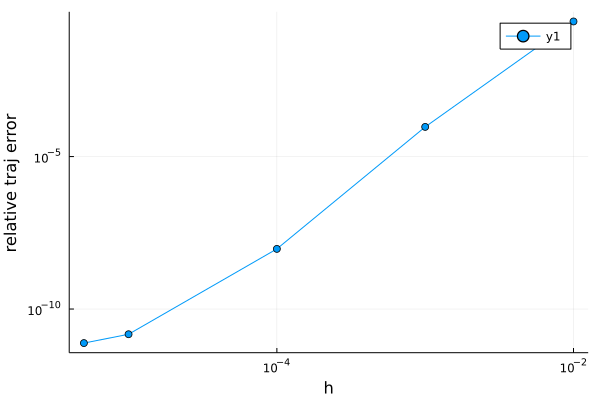

In [35]:
errors = [compute_traj_err(res[i], ref_sol) for i in 1:length(h_list)];
println("l2 norm of reference solution: ", norm(ref_sol))
println("relative trajectory errors: ", errors)

plot(h_list[1:end-1], errors[1:end-1], marker=:circle)
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative traj error")

energy of reference solution: 2.0000333333791707
relative energy errors: [0.2410245061583247, 1.6267748690613807e-7, 4.337347023389099e-12, 5.737981047323697e-12, 1.9079086737572013e-11, 0.0]


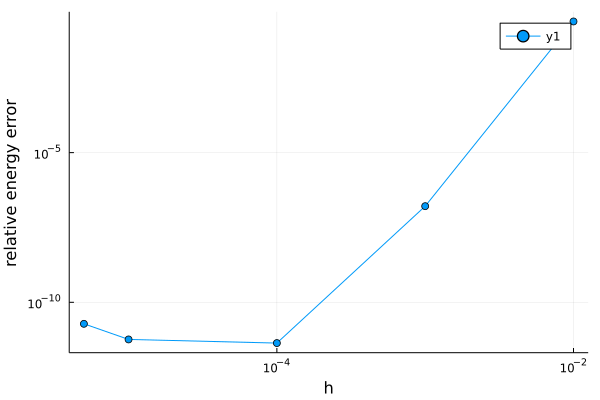

In [7]:
errors = [compute_H_err(res[i], ref_sol) for i in 1:length(h_list)];
println("energy of reference solution: ", compute_H(ref_sol...))
println("relative energy errors: ", errors)

plot(h_list[1:end-1], errors[1:end-1], marker=:circle)
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative energy error")

l2 norm of reference solution: 1.906537519123718335960434769391619081669481994007599256997806104386426519217363
relative trajectory errors: BigFloat[0.2695572215767734051085277757663475843156436003525350435932214647645510446696121, 9.391208172226494569908856253761110771843718605017834428660930889213689751374688e-05, 9.367544722333620016755673606315146603466505510365061763775807487347028724489558e-09, 9.344408061467534503905081372535421990038601378358822644306033400374804394814523e-13, 5.816926188740995291921989529350366514214047683516482598225731853551127328223344e-14, 0.0]


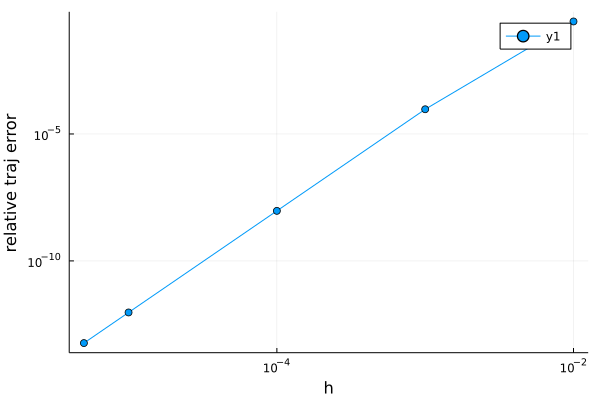

In [36]:
errors = [compute_traj_err(res_f128[i], ref_sol_f128) for i in 1:length(h_list)];
println("l2 norm of reference solution: ", norm(ref_sol_f128))
println("relative trajectory errors: ", errors)

plot(h_list[1:end-1], errors[1:end-1], marker=:circle)
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative traj error")

energy of reference solution: 2.000033333395056002274306794984887464551160831946572979541266767892776541992562
relative energy errors: BigFloat[0.2410245061485775880502618566130720360191729073302550294830064559711286705112723, 1.626853991118729367393568482659344148435699273006897880484529617625351204773575e-07, 4.657693383797349797054069749350811269002255958057194816222704443410446445385106e-12, 4.074464466364551825632735556292344081720257581579406717753803566099676179931239e-16, 3.186771686148039192957999483104031550749658550009390918733753441138510485845693e-17, 0.0]


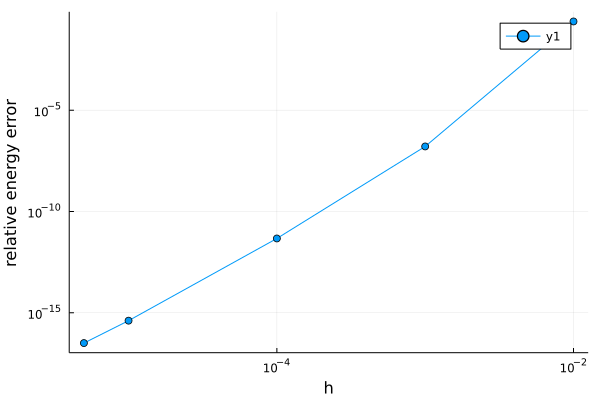

In [37]:
errors = [compute_H_err(res_f128[i], ref_sol_f128) for i in 1:length(h_list)];
println("energy of reference solution: ", compute_H(ref_sol_f128...))
println("relative energy errors: ", errors)

plot(h_list[1:end-1], errors[1:end-1], marker=:circle)
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative energy error")

In [94]:
for i in 1:length(h_list)
    println("\n\nh=", h_list[i])
#     println("\nFloat64:", res[i])
#     println("\nBigFloat:", convert(Tuple{Vector{Float64}, Vector{Float64}}, res_f128[end]))
    println("\nDiff:", res[i] .- convert(Tuple{Vector{Float64}, Vector{Float64}}, res_f128[end]))
    println("\nnorm of diff:", 
        norm(res[i] .- convert(Tuple{Vector{Float64}, Vector{Float64}}, res_f128[end])))
end



h=0.01

Diff:([-0.36323594832908124, 0.36320854160900906, 0.010388260667109628, -0.010383258069549206, 4.960791810487003e-6, -3.422796330723038e-6], [-0.004380482259804808, 0.00436277855847822, -3.953985337090682e-6, 1.1772253013242473e-5, 1.1588346029252003e-7, 9.367342118302147e-8])

norm of diff:0.5139209564867373


h=0.001

Diff:([0.00012660591556268308, -0.000126601312536348, -5.033522740838237e-7, 5.036465599017603e-7, -3.406836097952226e-10, 3.2498612134723714e-10], [4.110074288687926e-7, -4.1094029068489135e-7, 3.190860686785868e-9, -3.208653176489662e-9, 6.747939880480391e-13, 1.6920575184042885e-12])

norm of diff:0.00017904690735806705


h=0.0001

Diff:([1.2627284329269628e-8, -1.262675039526151e-8, -5.159750404715169e-11, 5.160594174213884e-11, -4.0342729157316626e-14, 3.925332281440319e-14], [4.104627748802159e-11, -4.106437412332298e-11, 3.223532551999142e-13, -3.0492275371329924e-13, 1.5191840840866888e-15, 1.5916087892087205e-15])

norm of diff:1.785754271538731e-8




In [84]:
res_f128

6-element Vector{Tuple{Vector{BigFloat}, Vector{BigFloat}}}:
 ([-1.822405777739618422270804341615404991622802849638689664249495183158773218786218, 0.3008016822682278961437632845422815814006541159364511661886843687277857801436053, 0.5709757832690999562140020790651908652314279162633172261718191058167790539850382, 0.5608290919655607990141314373420291277882308699245396981222387604837918171285296, 0.01990223861007342960406804999161870077783453663231960206254806054308422916912418, 0.01988122377940230415834491448619532305712935233818706282081785117206981025587754], [0.5267432166697943506893231203939265680599332376903548525032614880024979724300372, 0.5307216427464718184626837287593013932560238827830043660344176995861059527117128, 0.3881369484564995348373566974153053906384297329226841917669007439894936812603822, 0.3881687099013672831592497312123379935288400894435719425789022722886446493181822, 0.00280125977222870833175321428522763004538397089699433461767540329076453272834076, 0.0027987065975477

In [8]:
sol = phi_Dt(p0, q0, 4e-3)
println("relative traj relerr = ", compute_traj_err(sol, ref_sol))
println("relative energy relerr = ", compute_H_err(sol, ref_sol))

relative traj relerr = 0.025138804387933353
relative energy relerr = 0.0002004813545074719


In [9]:
phi_Dt_vv(p, q, h) = ode_solve(A, VelocityVerlet(), p, q, 0.0, Dt, round(Int, Dt/h), false);

In [10]:
h_list = [1e-3, 1e-4, 1e-5, 5e-6];
res = [phi_Dt_vv(p0, q0, h) for h in h_list];
errors = [compute_traj_err(res[i], ref_sol) for i in 1:length(h_list)];
print(errors)

[0.17899898605249723, 0.005881788624813169, 5.913790084584524e-5, 1.4785083612799417e-5]

## 2. Measure runtime

In [27]:
using BenchmarkTools

In [31]:
@benchmark phi_Dt(p0, q0, 5e-6, 1.0, 0.0)

BenchmarkTools.Trial: 3 samples with 1 evaluation.
 Range (min … max):  1.829 s …    2.365 s  ┊ GC (min … max): 40.11% … 57.90%
 Time  (median):     2.343 s               ┊ GC (median):    53.66%
 Time  (mean ± σ):   2.179 s ± 303.739 ms  ┊ GC (mean ± σ):  51.41% ±  9.29%

  █                                                      █ █  
  █▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁█ ▁
  1.83 s         Histogram: frequency by time         2.37 s <

 Memory estimate: 2.70 GiB, allocs estimate: 25000487.

In [32]:
@benchmark phi_Dt(p0_f128, q0_f128, BigFloat(5e-6), BigFloat(1.0), BigFloat(0.0))

BenchmarkTools.Trial: 1 sample with 1 evaluation.
 Single result which took 14.466 s (36.81% GC) to evaluate,
 with a memory estimate of 10.00 GiB, over 165001624 allocations.

In [5]:
Nsamples = 1000
P_init = repeat(p0, outer=(1, Nsamples));
Q_init = repeat(q0, outer=(1, Nsamples));

In [5]:
@benchmark map(phi_Dt, eachslice($P_init, dims=2), eachslice($Q_init, dims=2))

BenchmarkTools.Trial: 1 sample with 1 evaluation.
 Single result which took 29.312 s (12.56% GC) to evaluate,
 with a memory estimate of 37.52 GiB, over 410089212 allocations.

In [7]:
@benchmark pmap(phi_Dt, eachslice($P_init, dims=2), eachslice($Q_init, dims=2))

BenchmarkTools.Trial: 3 samples with 1 evaluation.
 Range (min … max):  1.811 s …   1.901 s  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     1.867 s              ┊ GC (median):    0.00%
 Time  (mean ± σ):   1.859 s ± 45.454 ms  ┊ GC (mean ± σ):  0.00% ± 0.00%

  █                                  █                    █  
  █▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  1.81 s         Histogram: frequency by time         1.9 s <

 Memory estimate: 427.69 KiB, allocs estimate: 8218.

## 3. Measure stability 

In [13]:
p0_ptb = p0 .+ 1e-14;
q0_ptb = q0 .+ 1e-14;

In [96]:
p0_ptb_f128 = p0_f128 .+ 1e-14
q0_ptb_f128 = q0_f128 .+ 1e-14

6-element Vector{BigFloat}:
 0.7047497585826023671620785171398774929630829525025963432907291639217817191820359
 0.7094638037905126672902408790832733013022019100221275932907291639217817191820359
 9.999999999999999988193093545598986971343290729163921781719182035885751247406006e-15
 9.999999999999999988193093545598986971343290729163921781719182035885751247406006e-15
 9.999999999999999988193093545598986971343290729163921781719182035885751247406006e-15
 9.999999999999999988193093545598986971343290729163921781719182035885751247406006e-15

In [15]:
p0_ptb

6-element Vector{Float64}:
 1.0e-14
 1.4142135623731051
 1.0e-14
 1.0e-14
 1.0e-14
 1.0e-14

In [43]:
N = 200
res = []
for h in [1e-3, 1e-4, 1e-5, 5e-6]
    P, Q = phi_Dt_N(p0, q0, N, h)
    P_ptb, Q_ptb = phi_Dt_N(p0_ptb, q0_ptb, N, h)
    push!(res, (h, P, Q, P_ptb, Q_ptb))
end

In [ ]:
N = 100
stability_res_f128 = []
for h in [1e-3, 1e-4, 1e-5, 5e-6]
    P_f128, Q_f128 = phi_Dt_N(p0_f128, q0_f128, N, BigFloat(h), BigFloat(1.0), BigFloat(0.0))
    P_ptb_f128, Q_ptb_f128 = phi_Dt_N(p0_ptb_f128, q0_ptb_f128, N, BigFloat(h), BigFloat(1.0), BigFloat(0.0))
    push!(stability_res_f128, (h, P_f128, Q_f128, P_ptb_f128, Q_ptb_f128))
end

┌ Warning: Skipped xaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76


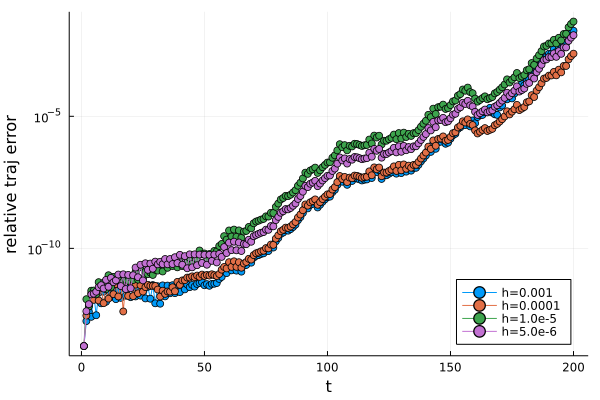

In [45]:
errors = []
for (h, P, Q, P_ptb, Q_ptb) in res
    errors_h = []
    for n in 1:N
        err = compute_traj_err((P_ptb[:, n], Q_ptb[:, n]), (P[:, n], Q[:, n]))
        push!(errors_h, err)
    end
    push!(errors, (h, errors_h))
end 

plot()
for (h, errors_h) in errors
    plot!((1:N)*Dt, errors_h, marker=:circle, label="h=$h")
end
plot!(xaxis=:linear, yaxis=:log)
plot!(xlabel="t", ylabel="relative traj error")
plot!(legend=:bottomright)

┌ Warning: Skipped xaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76


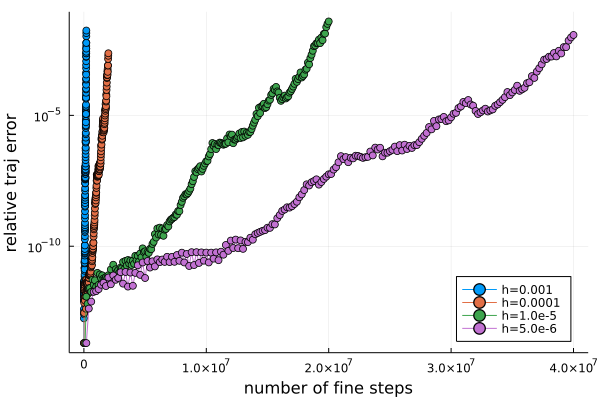

In [46]:
plot()
for (h, errors_h) in errors
    plot!((1:N)*Dt/h, errors_h, marker=:circle, label="h=$h")
end
plot!(xaxis=:linear, yaxis=:log)
plot!(xlabel="number of fine steps", ylabel="relative traj error")
plot!(legend=:bottomright)

┌ Warning: Skipped xaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76


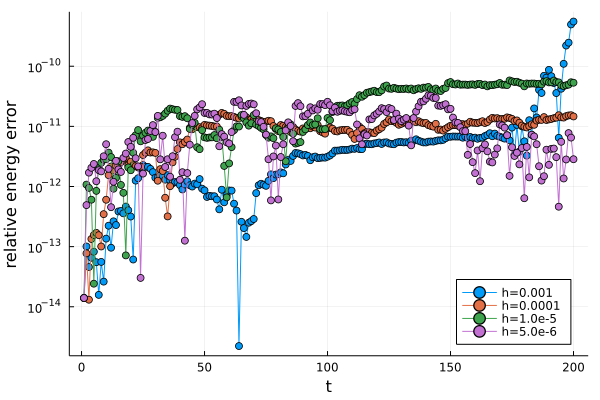

In [47]:
errors = []
for (h, P, Q, P_ptb, Q_ptb) in res
    errors_h = []
    for n in 1:N
        err = compute_H_err((P_ptb[:, n], Q_ptb[:, n]), (P[:, n], Q[:, n]))
        push!(errors_h, err)
    end
    push!(errors, (h, errors_h))
end 

plot()
for (h, errors_h) in errors
    plot!((1:N)*Dt, errors_h, marker=:circle, label="h=$h")
end
plot!(xaxis=:linear, yaxis=:log)
plot!(xlabel="t", ylabel="relative energy error")
plot!(legend=:bottomright)

┌ Warning: Skipped xaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76


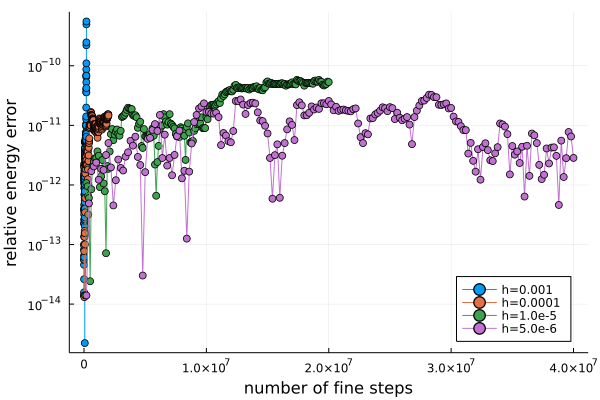

In [48]:
plot()
for (h, errors_h) in errors
    plot!((1:N)*Dt/h, errors_h, marker=:circle, label="h=$h")
end
plot!(xaxis=:linear, yaxis=:log)
plot!(xlabel="number of fine steps", ylabel="relative energy error")
plot!(legend=:bottomright)

In [50]:
include("./generate_data_utils.jl")

for (h, P, Q, P_ptb, Q_ptb) in res
    save("./stability/h=$h/sol.csv", P, Q)
    save("./stability/h=$h/sol_ptb.csv", P_ptb, Q_ptb)
end 

In [54]:
p0

6-element Vector{Float64}:
 0.0
 1.4142135623730951
 0.0
 0.0
 0.0
 0.0

## 4. BigFloat

In [40]:
P, Q = phi_Dt_N(p0, q0, 50, 5e-6, 1.0, 0.0)

([0.0 -1.459169829415611 … 0.15388314221468322 1.0567920117951832; 1.4142135623730951 -0.062406859335768505 … -0.04081550669933136 -0.9133854894865938; … ; 0.0 0.019897277818259094 … -0.9008043241614703 0.1247403847669647; 0.0 0.019884646575740593 … -0.8990648191791544 0.1409354341159973], [0.7047497585825924 0.531123698929628 … -0.2214689914432798 -0.16045150347886764; 0.7094638037905027 0.5263588641879523 … -0.22805254835993555 -0.15966030847558457; … ; 0.0 0.0028011438887687087 … -0.23210811611528281 -0.855268310937831; 0.0 0.0027986129241268773 … -0.2320557412114487 -0.8552713550409551])

In [41]:
P_f128, Q_f128 = phi_Dt_N(p0_f128, q0_f128, 50, BigFloat(5e-6), BigFloat(1.0), BigFloat(0.0))

(BigFloat[0.0 -1.459169829410368779410161784367368445764580777356868377090088865346787703527058 … 0.153883142197898447459867869267899584845706459839831770316691039554414047787873 1.056792011754082424217698320397003829080256478283381746411884258694009175119336; 1.4142135623730951454746218587388284504413604736328125 -0.06240685934094658668617253151020743106591186865585106338968688369431157319456272 … -0.04081550666286182836152679895766042230333674188620469368276366976877001072722253 -0.9133854894206951802539449931766712595576551917786161802830000035166924614302262; … ; 0.0 0.01989727781826293693669555687120337467943414660988347940208474367409642489088191 … -0.9008043241778759871677151317483574854960168111654298444517701885203549290247782 0.1247403847319666422548981197141929261282983349274500706020902000057239613333535; 0.0 0.01988464657573288011280146527608779131637330867655726159684885660544150592626029 … -0.899064819160774009810251844274920577132124088051368876367795189672339369095168 

In [79]:
P_largeh, Q_largeh = phi_Dt_N(p0, q0, 50, 1e-3, 1.0, 0.0)

([0.0 -1.4590432234948845 … 0.16256231460742523 1.055688663552182; 1.4142135623730951 -0.06253346065340452 … -0.04949467815730865 -0.9122821829356766; … ; 0.0 0.019897277477579328 … -0.9008724627930322 0.124749975854537; 0.0 0.019884646900719 … -0.8989966827582336 0.14092593609340973], [0.7047497585825924 0.5311241099370279 … -0.2214719548544625 -0.16048094557824935; 0.7094638037905027 0.5263584532477026 … -0.22804954128077834 -0.15963085832378013; … ; 0.0 0.002801143889443199 … -0.23210808941902575 -0.8552680708855828; 0.0 0.0027986129258186017 … -0.23205576778981854 -0.8552715991319789])

In [80]:
P_largeh_f128, Q_largeh_f128 = phi_Dt_N(p0_f128, q0_f128, 50, BigFloat(1e-3), BigFloat(1.0), BigFloat(0.0))

(BigFloat[0.0 -1.459043223494921486034732857067443027089302437303272158650577608463691832208682 … 0.1625623146058414712332515675335524554811923429696682872193397739052510001950151 1.055688663553414104621560153630360664739638090105459069036935609892212752837863; 1.4142135623730951454746218587388284504413604736328125 -0.06253346065336396933226171288617925326730032544544775700384903021752907977285967 … -0.04949467815479272141592775160507397992099806594741267267390737380797048436786536 -0.9122821829357280323125240359818209005580117638258297850598021427894253953344967; … ; 0.0 0.01989727747757892664766949901717341389344570475481204965900869393471343208250479 … -0.9008724627924572862999861597548865105092238393871901951017414021921896142338823 0.1247499758579157242114842835912386134237314984519857929019926258467121317885324; 0.0 0.01988464690071951244364354779394272547761549035005274246472580097735468147009534 … -0.898996682758682008963054548726487533917141788700133127317513882270957299301321

In [81]:
P_convert = convert( Matrix{BigFloat}, P);
Q_convert = convert( Matrix{BigFloat}, Q);
P_largeh_convert = convert( Matrix{BigFloat}, P_largeh);
Q_largeh_convert = convert( Matrix{BigFloat}, Q_largeh);

┌ Warning: Skipped xaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76
┌ Warning: Skipped yaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76


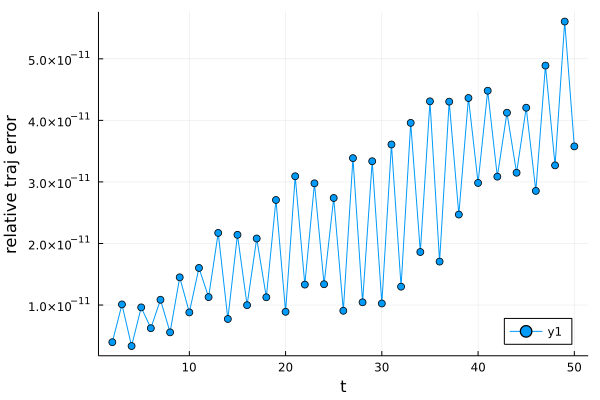

In [51]:
errors = []
for n in 1:50
    err = compute_traj_err((P[:, n], Q[:, n]), (P_f128[:, n], Q_f128[:, n]))
    push!(errors, err)
end

plot()
plot!((2:50), errors[2:end], marker=:circle)
plot!(xaxis=:linear, yaxis=:linear)
plot!(xlabel="t", ylabel="relative traj error")
plot!(legend=:bottomright)

┌ Warning: Skipped xaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76
┌ Warning: Skipped yaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76


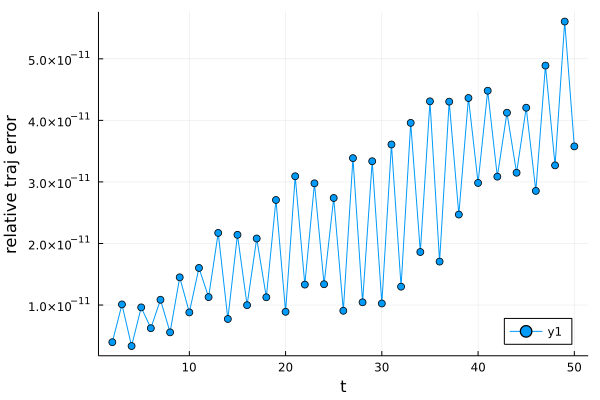

In [70]:
errors = []
for n in 1:50
    err = compute_traj_err((P_convert[:, n], Q_convert[:, n]), (P_f128[:, n], Q_f128[:, n]))
    push!(errors, err)
end

plot()
plot!((2:50), errors[2:end], marker=:circle)
plot!(xaxis=:linear, yaxis=:linear)
plot!(xlabel="t", ylabel="relative traj error")
plot!(legend=:bottomright)

┌ Warning: Skipped xaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76
┌ Warning: Skipped yaxis arg linear
└ @ Plots /workspace/project_Rui/.julia/packages/Plots/qbc7U/src/axes.jl:76


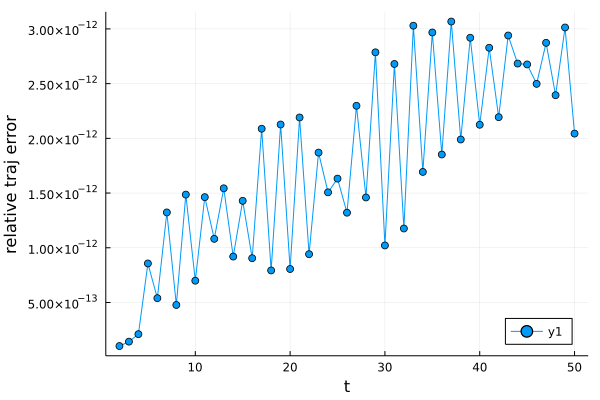

In [82]:
errors = []
for n in 1:50
    err = compute_traj_err((P_largeh_convert[:, n], Q_largeh_convert[:, n]), 
        (P_largeh_f128[:, n], Q_largeh_f128[:, n]))
    push!(errors, err)
end

plot()
plot!((2:50), errors[2:end], marker=:circle)
plot!(xaxis=:linear, yaxis=:linear)
plot!(xlabel="t", ylabel="relative traj error")
plot!(legend=:bottomright)

## Find CalvoSanz and Velocity Verlet step sizes that generate similar level of accuracy as NN

In [19]:
@everywhere begin 
    
    phi_Dt_CS(p, q, h_CS) = ode_solve(A, CalvoSanz4(), p, q, 0.0, Dt, round(Int, Dt/h_CS), false)
    phi_Dt_VV(p, q, h_VV) = ode_solve(A, VelocityVerlet(), p, q, 0.0, Dt, round(Int, Dt/h_VV), false)
    
end

In [1]:
using CSV 
using DataFrames

In [2]:
df_init = DataFrame(CSV.File("../data/fpu/Dt1e0_dt1e-2_h5e-5/400traj/test/X.csv"));
df_final = DataFrame(CSV.File("../data/fpu/Dt1e0_dt1e-2_h5e-5/400traj/test/Y.csv"));

In [14]:
div(size(df_init)[2], 2)

6

In [15]:
df_init[:, 1:3]

,p1,p2,p3
,Float64,Float64,Float64
1,1.20737,-0.279278,-0.745425
2,0.214214,-1.1025,0.434747
3,-0.357103,0.800476,-0.340655
4,-1.49277,-0.210345,0.0403567
5,0.0136592,1.45386,0.601766
6,0.357872,0.519819,-0.17021
7,0.0412103,1.39902,-0.474584
8,-0.680954,0.810106,0.168413
9,0.460773,0.0431027,-0.000468713


In [12]:
l = 1
nsamples = 40080
P_init = Matrix(df_init[1:l:nsamples, 1:6])'; 
Q_init = Matrix(df_init[1:l:nsamples, 7:12])';
P_final = Matrix(df_final[1:l:nsamples, 1:6])'; 
Q_final = Matrix(df_final[1:l:nsamples, 7:12])';

In [21]:
function accuracy_VV(timestep)
    res = pmap((p, q)->phi_Dt_VV(p, q, timestep), eachslice(P_init, dims=2), eachslice(Q_init, dims=2));

    P_VV = hcat([p for (p, q) in res]...);
    Q_VV = hcat([q for (p, q) in res]...);

    SE = sum((P_VV - P_final) .^2, dims=1) + sum((Q_VV - Q_final) .^2, dims=1);
    MSE = sum(SE)/length(SE);

    return MSE 
end 

accuracy_VV (generic function with 1 method)

In [23]:
function accuracy_CS(timestep)
    res = pmap((p, q)->phi_Dt_CS(p, q, timestep), eachslice(P_init, dims=2), eachslice(Q_init, dims=2));

    P_CS = hcat([p for (p, q) in res]...);
    Q_CS = hcat([q for (p, q) in res]...);

    SE = sum((P_CS - P_final) .^2, dims=1) + sum((Q_CS - Q_final) .^2, dims=1);
    MSE = sum(SE)/length(SE);

    return MSE 
end 

accuracy_CS (generic function with 1 method)

In [22]:
for nsteps_VV in [32, 64, 128]
    h_VV = Dt/nsteps_VV
    println(h_VV, " ", nsteps_VV, " ", accuracy_VV(h_VV))
end

0.03125 32 0.6278326283974353
0.015625 64 1.4437819082575212
0.0078125 128 0.10294198825932901


In [24]:
for nsteps_CS in [8, 16, 32]
    h_CS = Dt/nsteps_CS
    println(h_CS, " ", nsteps_CS, " ", accuracy_CS(h_CS))
end

0.125 8 12.113986319436153
0.0625 16 20.929485064488254
0.03125 32 0.0005649300775061397


In [25]:
for nsteps_CS in [64, 128]
    h_CS = Dt/nsteps_CS
    println(h_CS, " ", nsteps_CS, " ", accuracy_CS(h_CS))
end

0.015625 64 2.034209929224812e-6
0.0078125 128 7.768522155694077e-9


In [30]:
@time for i in 1:1000 phi_Dt_VV(v0, x0, 1.5625e-5) end 

  1.069980 seconds (14.36 M allocations: 1.330 GiB, 22.04% gc time)


In [33]:
@time for i in 1:64 phi_Dt_CS(p0, q0, Dt/64) end 

  0.832354 seconds (11.10 M allocations: 1022.842 MiB, 21.92% gc time)


In [16]:
using Plots

In [107]:
histogram(vec(SE))

LoadError: InexactError: trunc(Int64, 2.3271148548353484e40)

In [139]:
H_init = pmap(compute_hamiltonian, eachslice(V_init, dims=2), eachslice(X_init, dims=2));
H_final = pmap(compute_hamiltonian, eachslice(V_final, dims=2), eachslice(X_final, dims=2));

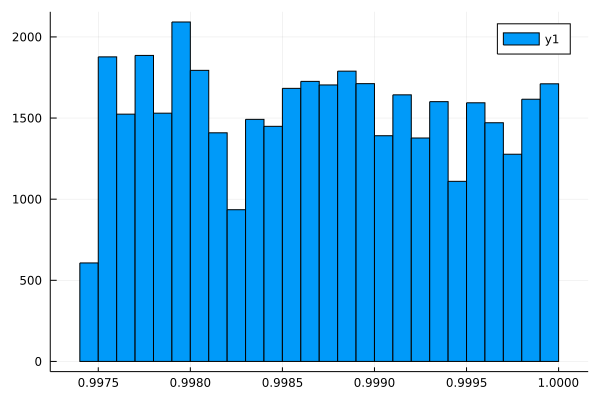

In [140]:
histogram(vec(H_init/H0))

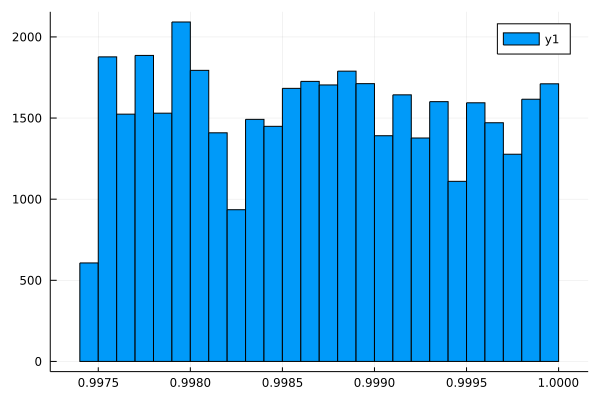

In [141]:
histogram(vec(H_final/H0))